# **netflix Data Insights**

## Objectives

The objective of this notebook is to generate visualisations based on the cleaned Netflix dataset.  
I reload the raw dataset, repeat the essential cleaning steps, and create charts that communicate insights clearly, such as:
* Movies vs TV Shows over time
* Top genres
* Top countries
* Duration distributions
* Actor and director frequency charts


## Inputs

* Raw dataset: `netflix_titles.csv`
* Cleaning steps reproduced from the ETL notebook
* Python libraries: pandas, numpy, matplotlib, seaborn
 

## Outputs

* Visualisations including:
  - Line charts
  - Bar charts
  - Histograms
* Cleaned DataFrame used only within this notebook
* No external files are saved
 

## Additional Comments

This notebook repeats the ETL cleaning steps to ensure reproducibility.  
No cleaned dataset is saved — all transformations are performed directly before visualisation.




---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\ovrcm\\OneDrive\\Documents\\vscode-projects\\netflix-data-analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\ovrcm\\OneDrive\\Documents\\vscode-projects\\netflix-data-analysis'

# Section 1

 import  libaries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


## 1. Load Dataset

In [20]:
df = pd.read_csv('Dataset/RawData/netflix_titles.csv')
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


---



## 2. Cleaning Steps (ETL Repeated)

To ensure the visualisations are accurate, I repeat the essential ETL cleaning steps from the first notebook.  
This keeps the project reproducible and avoids relying on saved cleaned files.





In [27]:
df['director'] = df['director'].fillna('unknown')
df['cast'] = df['cast'].fillna('unknown')
df['country'] = df['country'].fillna('unknown')
df['rating'] = df['rating'].fillna('unknown')

df['duration'] = (df['duration'].astype(str)
                  .replace(' min', '')
                  .replace(' season', '')
                  .replace(' seasons', '')
)
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['release_year'] = df['release_year'].astype(int)

df['cast_list'] = df['cast'].apply(lambda x: [actor.strip() for actor in x.split(',')])
df['genre_list'] = df['listed_in'].apply(lambda x: [genre.strip() for genre in x.split(',')])
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,cast_list,genre_list,country_list
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90.0,Documentaries,"As her father nears the end of his life, filmm...",[Unknown],[Documentaries],[United States]
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2.0,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...","[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba...","[International TV Shows, TV Dramas, TV Mysteries]",[South Africa]
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1.0,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab...","[Crime TV Shows, International TV Shows, TV Ac...",[Unknown]
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1.0,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",[Unknown],"[Docuseries, Reality TV]",[Unknown]
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2.0,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ...","[International TV Shows, Romantic TV Shows, TV...",[India]
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1.0,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,"[Kate Siegel, Zach Gilford, Hamish Linklater, ...","[TV Dramas, TV Horror, TV Mysteries]",[Unknown]
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91.0,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,"[Vanessa Hudgens, Kimiko Glenn, James Marsden,...",[Children & Family Movies],[Unknown]
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125.0,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...","[Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra ...","[Dramas, Independent Movies, International Mov...","[United States, Ghana, Burkina Faso, United Ki..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9.0,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,"[Mel Giedroyc, Sue Perkins, Mary Berry, Paul H...","[British TV Shows, Reality TV]",[United Kingdom]
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104.0,"Comedies, Dramas",A woman adjusting to life after a loss contend...,"[Melissa McCarthy, Chris O'Dowd, Kevin Kline, ...","[Comedies, Dramas]",[United States]


### 3. Content Added Over Time

Here I look at how many titles were added to Netflix each year.  
This helps show how Netflix’s library has grown over time.


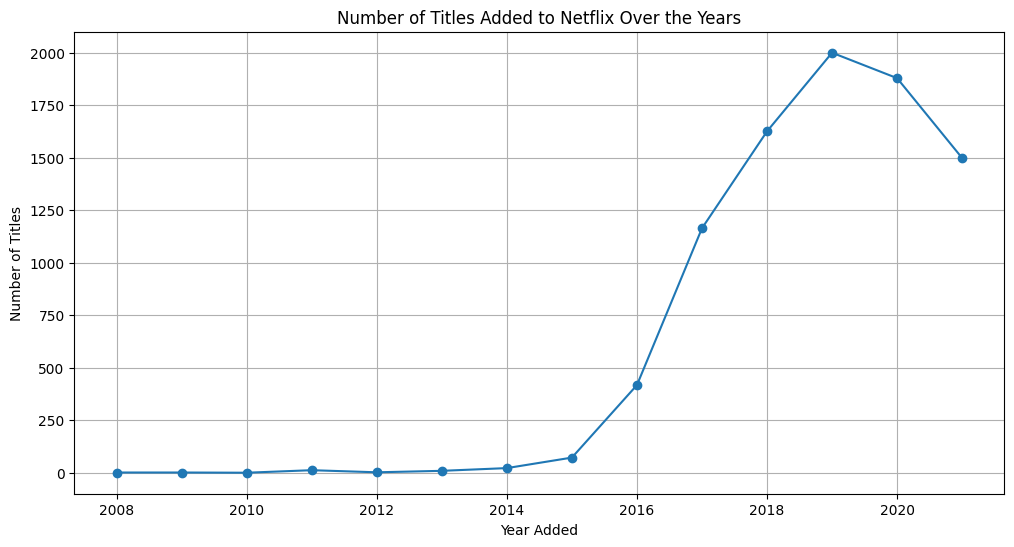

In [28]:
df['year_added'] = df['date_added'].dt.year
content_per_year = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.plot(content_per_year.index, content_per_year.values, marker='o')
plt.title('Number of Titles Added to Netflix Over the Years')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

**Insight:**  
There is a clear increase in content added in later years, showing strong growth in Netflix’s catalogue.

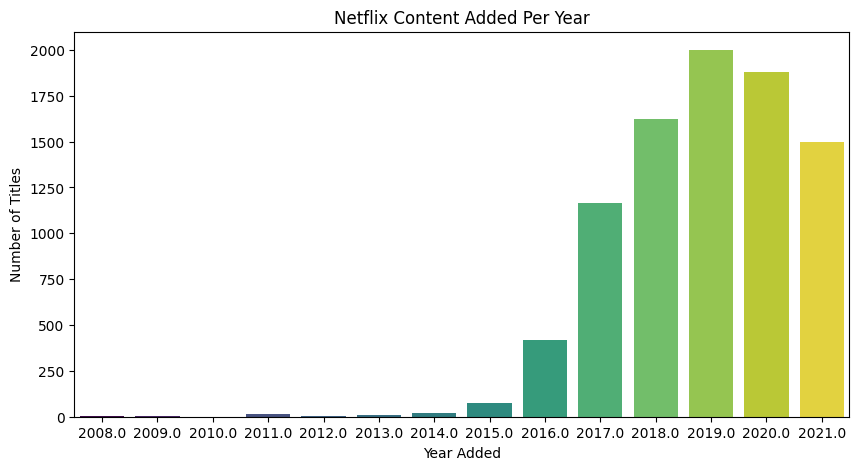

In [30]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=content_per_year.index,
    y=content_per_year.values,
    hue=content_per_year.index,
    palette='viridis',
    legend=False
)
plt.title('Netflix Content Added Per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

**Insight:**  
The bar chart makes the growth even clearer — recent years show a much higher number of new titles compared to earlier years.

---
### 4. Movies vs TV Shows

Here I compare how many Movies and TV Shows are available on Netflix.  
This helps show which type of content is more common on the platform.

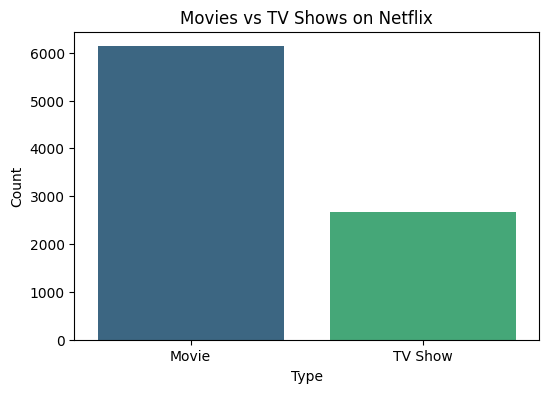

In [32]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', hue='type', palette='viridis', legend=False)
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

**Insight:**  
Movies appear more frequently than TV Shows, meaning Netflix’s catalogue leans more towards films.

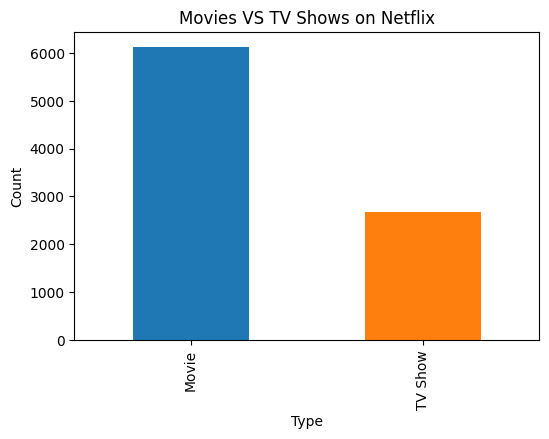

In [33]:
type_counts = df['type'].value_counts()
plt.figure(figsize=(6, 4))
type_counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Movies VS TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

**Insight:**  
The bar chart confirms the same pattern — Movies make up a larger portion of Netflix’s content library.

---
### 5. Top Countries

Here I look at which countries produce the most Netflix content.  
This helps show whether Netflix relies heavily on certain regions.

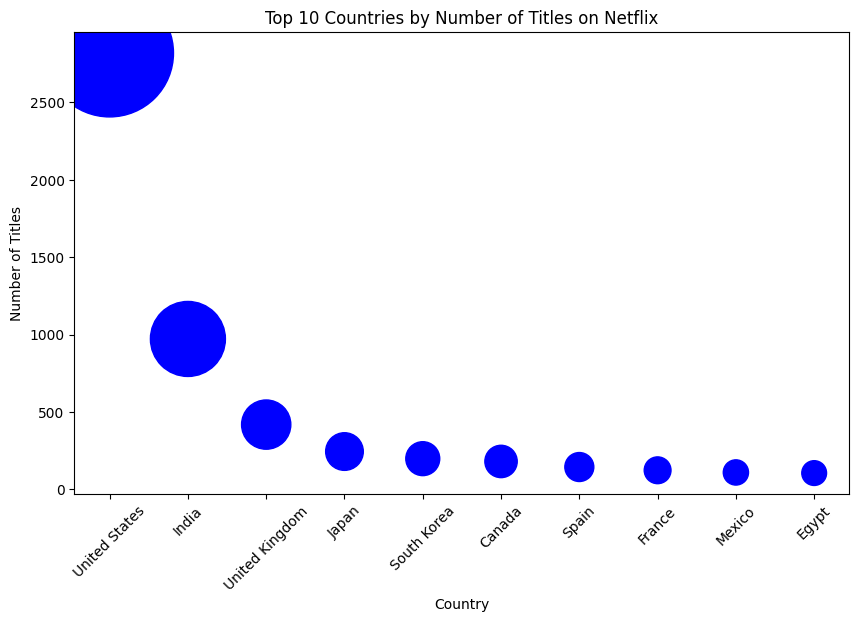

In [61]:
top_countries = df_clean['country'].value_counts().head(10)
top_countries = df_clean['country'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.scatter(top_countries.index, top_countries.values, s=top_countries.values * 3, color='blue'
)
plt.title('Top 10 Countries by Number of Titles on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

**Insight:**  
The scatter plot shows clear “standout” countries — especially the USA — producing far more content than others.

In [59]:
df_clean = df[df['country'] != 'Unknown']
top_countries = df_clean['country'].value_counts().head(10).reset_index()
top_countries.columns = ['country', 'count']

fig = px.scatter(
    top_countries,
    x='country',
    y='count',
    size='count',
    color='country',
    title='Top 10 Countries Producing Netflix Content (Interactive)',
    labels={'country': 'Country', 'count': 'Number of Titles'}
)
fig.show()

**Insight:**  
The interactive chart shows that a few countries — especially the USA — produce far more Netflix content than others. Larger bubbles represent countries with more titles.

---
### 6. Top Genres
Here I look at which genres appear most often on Netflix.  
This helps show what types of content Netflix focuses on.

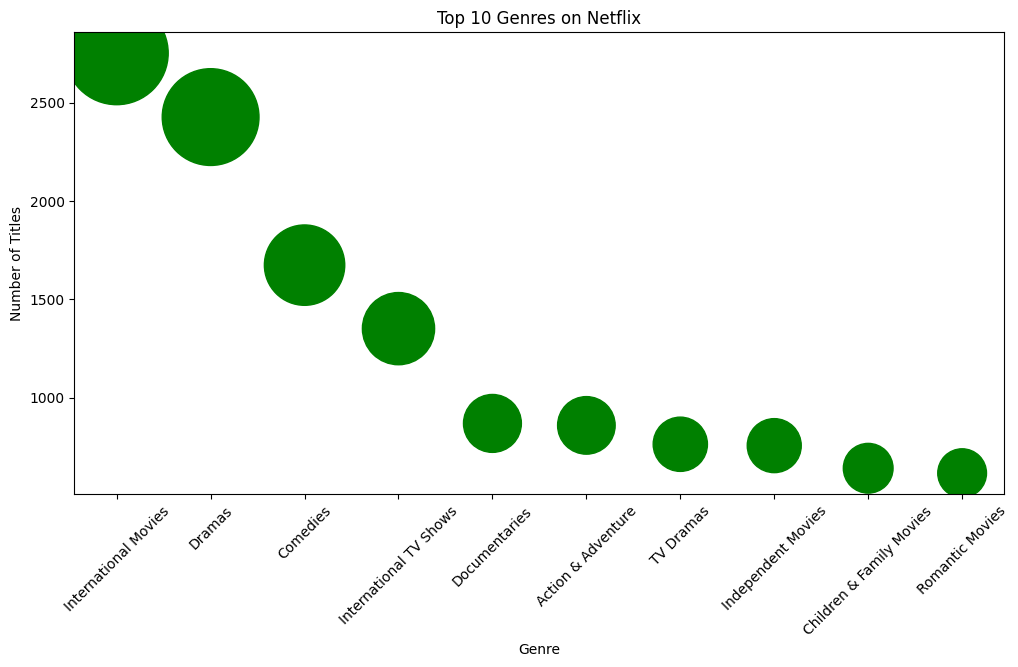

In [41]:
genres = df['genre_list'].explode()
top_genres = genres.value_counts().head(10)
plt.figure(figsize=(12, 6))
plt.scatter(
top_genres.index, top_genres.values, s=top_genres.values * 2, color='green'
)
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

**Insight:**  
The bubble chart shows that genres like Drama and Comedy appear far more often than others, making them the most dominant categories on Netflix.

In [45]:
top_genres_df = top_genres.reset_index()
top_genres_df.columns = ['genre', 'count']
fig = px.bar(
    top_genres_df,
    x='count',
    y='genre',
    orientation='h',
    title='Top 10 Genres on Netflix (Interactive)',
    labels={'genre': 'Genre', 'count': 'Number of Titles'},
    color='count',
)
fig.show()

**Insight:**  
The interactive chart makes it easy to compare genres. Drama and Comedy clearly stand out as the most frequent genres on the platform.

---
### 7. Ratings Distribution

Here I look at the maturity ratings of Netflix content.  
This helps show whether Netflix has more family‑friendly or mature content.


In [50]:
rating_df = rating_counts.reset_index()
rating_df.columns = ['rating', 'count']

fig = px.bar(
    rating_df,
    x='count',
    y='rating',
    orientation='h',
    title='Distribution of Netflix Content Ratings (Interactive)',
    labels={'rating': 'Rating', 'count': 'Number of Titles'},
    color='count'
)
fig.show()

**Insight:**  
The interactive chart shows that mature ratings — especially **TV‑MA** — make up the largest portion of Netflix’s catalogue.  
This suggests that Netflix leans heavily toward content aimed at adult audiences rather than family‑friendly categories.

C:\Users\ovrcm\AppData\Local\Temp\ipykernel_15096\1612793248.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




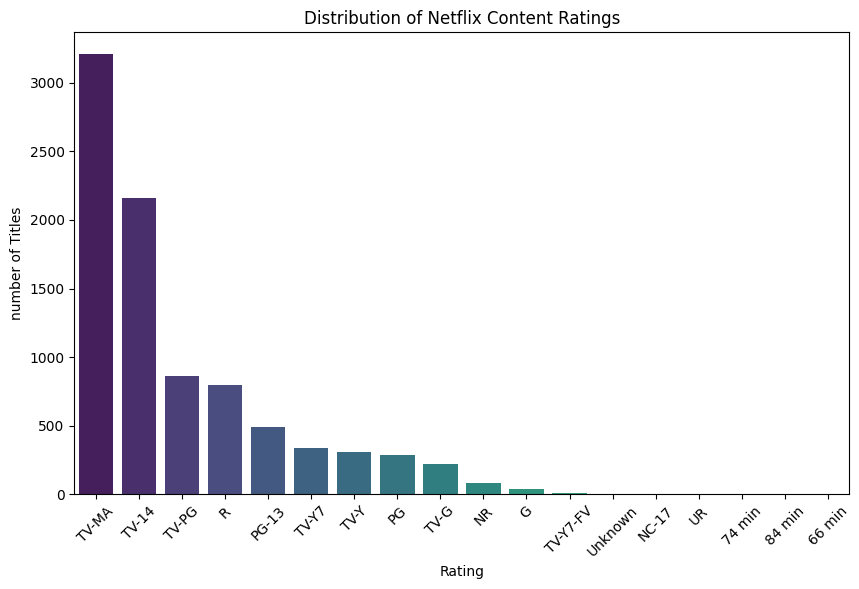

In [54]:
rating_counts = df['rating'].value_counts()
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='rating',
    order=df['rating'].value_counts().index,
    palette='viridis',
)
plt.title('Distribution of Netflix Content Ratings')
plt.xlabel('Rating')
plt.ylabel('number of Titles')
plt.xticks(rotation=45)
plt.show()



**Insight:**  
The countplot clearly shows that mature ratings such as **TV‑MA** dominate Netflix’s catalogue.  
This supports the hypothesis that most Netflix content is aimed at adult audiences rather than younger viewers.

---

---

# final conclusion

### Conclusion

This visualisation notebook presents the insights from the Netflix dataset in a clear and easy‑to‑understand way.  
Each chart supports the findings from the ETL and EDA work, showing trends in content over time, the balance between movies and TV shows, the top countries producing content, the most common genres, and the distribution of maturity ratings.

The visuals make the results simple to interpret and help communicate the main patterns in the data effectively.  
Overall, the visualisations give a clear picture of Netflix’s content and support the conclusions drawn earlier in the analysis.